In [2]:
from pest import FitsDataset

ds = FitsDataset("/urz/gpuscratch/its/doserbd/data/SKIRT_synthetic_images/fits")
print(len(ds))

58033


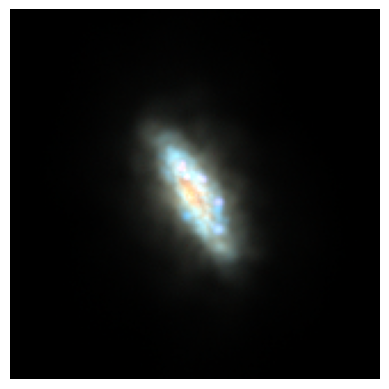

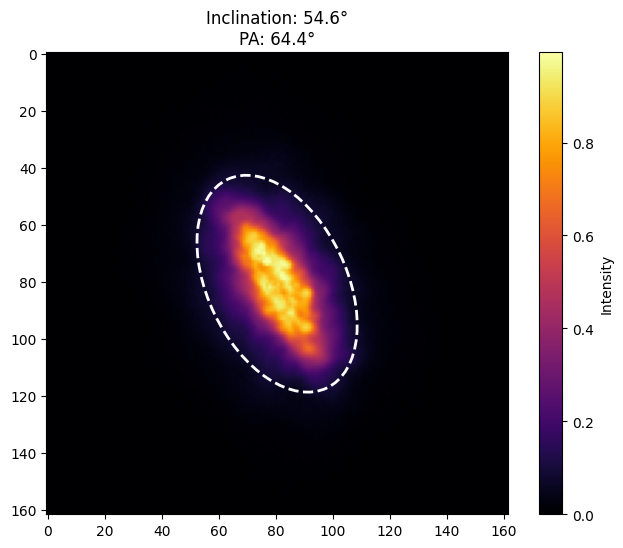

In [3]:
import matplotlib.pyplot as plt
from pest import estimate_geometry_weighted, visualize_results

plt.rcParams["text.usetex"] = False

image = ds[50002].transpose(1, 2, 0)
plt.imshow(image)
plt.axis("off")
plt.show()

stats = estimate_geometry_weighted(image)
visualize_results(stats)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0015401723311239748..1.0269954917549509].


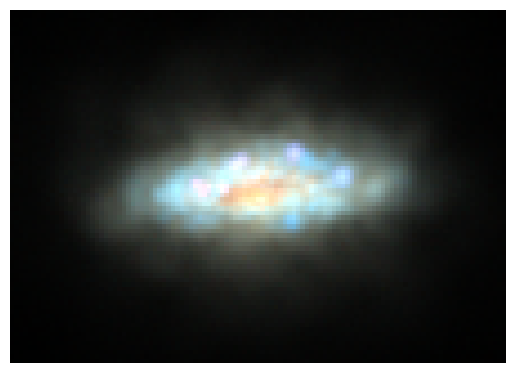

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rotate as nd_rotate
from pest import estimate_geometry_weighted

# Ellipse parameters from stats
x_c, y_c = stats["centroid"]
a = stats["major_axis"]
b = stats["minor_axis"]
theta = stats["pa_rad"]

# Rotate image so that the major axis is horizontal.
# theta is the angle of the major axis from the column (x) direction;
# rotating by np.degrees(theta) CCW aligns the major axis with the horizontal axis.
rotation_deg = np.degrees(theta)
rotated = nd_rotate(image, rotation_deg, reshape=True)

# Re-estimate geometry on the rotated image to get the updated centroid
stats_rot = estimate_geometry_weighted(rotated.copy())
x_c2, y_c2 = stats_rot["centroid"]
a2 = stats_rot["major_axis"]
b2 = stats_rot["minor_axis"]

MARGIN = 10

# After rotation the major axis is horizontal, so bounding box is a2 wide and b2 tall
col_min = int(np.floor(x_c2 - a2 - MARGIN))
col_max = int(np.ceil(x_c2 + a2 + MARGIN))
row_min = int(np.floor(y_c2 - b2 - MARGIN))
row_max = int(np.ceil(y_c2 + b2 + MARGIN))

H2, W2 = rotated.shape[:2]
col_min = max(0, col_min)
col_max = min(W2, col_max)
row_min = max(0, row_min)
row_max = min(H2, row_max)

scaled = rotated[row_min:row_max, col_min:col_max]

plt.imshow(scaled)
plt.axis("off")
plt.show()
